In this notebook, we use our test cases to ask the same question and query the same data using two different approaches:

- On one side, we use the traditional SQL stack, where an LLM generates SQL queries to fetch data from a SQL database.
- On the other, we use a JavaScript stack, where an LLM generates JavaScript queries to fetch data from a JSON object in a file.

We have 100 test cases across 4 categories, with test results stored as pandas DataFrames in the following files:
- `data/result_sql.pkl`
- `data/result_js.pkl`

We compare the number of correct answers for both the SQL and JavaScript approaches.

In [4]:
import pandas as pd

df_sql= pd.read_pickle("data/result_sql.pkl")
df_js= pd.read_pickle("data/result_js.pkl")

After loading the pandas DataFrames, we replace the short category labels with their long-form versions.

In [5]:
category_labels={
    "va":"variant",
    "yes":"basic",
    "no":"none",
    "ex":"extra"
}

for irow  in range(len(df_js['category'])):
    label_long=category_labels[df_js['category'].iloc[irow]]
    df_js.loc[irow, 'category']=label_long

for irow  in range(len(df_sql['category'])):
    label_long=category_labels[df_sql['category'].iloc[irow]]
    df_sql.loc[irow, 'category']=label_long


We now calculate the number of successful tests in each category.

In [13]:
df_sql_g=df_sql.groupby(['category']).sum('okAnswer')
df_js_g=df_js.groupby(['category']).sum('okAnswer')
df_sql_g['JavaScript']=df_js_g['okAnswer']
df_g=df_sql_g.rename(columns={'okAnswer': 'SQL'})
df_g

,SQL,JavaScript
category,,
basic,21,23
extra,25,22
none,19,23
variant,16,22


A bar chart provides a visual **presentation** of the results.

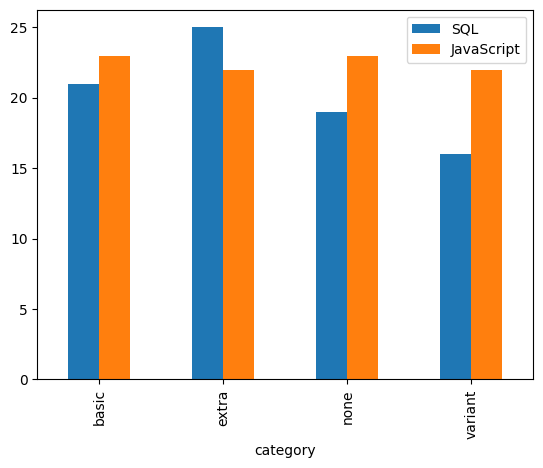

In [14]:
ax = df_g.plot.bar()

The total number of correct answers for the JavaScript stack **and** the SQL stack **is**:

In [15]:
df_g.sum()

SQL           81
JavaScript    90
dtype: int64